In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [4]:
kaggle_df = pd.read_csv('/content/trajectory_timeseries.csv',
                        engine='python', on_bad_lines='skip')

cols = ['altitude_km','inclination','eccentricity','mean_motion']
kaggle_df = kaggle_df[cols].copy()

for c in cols:
    kaggle_df[c] = pd.to_numeric(kaggle_df[c], errors='coerce')

kaggle_df = kaggle_df.dropna()

In [5]:
def clean(df):
    features = ['INCLINATION','ECCENTRICITY','MEAN_MOTION']
    df = df[features].copy()
    df = df.apply(pd.to_numeric, errors='coerce')
    return df.dropna()

active = clean(pd.read_csv('/content/active.csv'))
starlink = clean(pd.read_csv('/content/starlink.csv'))
station = clean(pd.read_csv('/content/spacestation.csv'))

combined = pd.concat([active, starlink, station])

In [6]:
mu = 398600

def mean_motion_to_altitude(n):
    n = n * 2*np.pi / 86400
    a = (mu/(n**2))**(1/3)
    return a - 6371

combined['altitude_km'] = combined['MEAN_MOTION'].apply(mean_motion_to_altitude)

combined = combined.rename(columns={
    'INCLINATION':'inclination',
    'ECCENTRICITY':'eccentricity',
    'MEAN_MOTION':'mean_motion'
})

combined = combined[['altitude_km','inclination','eccentricity','mean_motion']]

In [7]:
final_df = pd.concat([kaggle_df, combined], ignore_index=True)
final_df = final_df.dropna().reset_index(drop=True)

scaler = MinMaxScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(final_df), columns=cols)

In [8]:
def create_seq(data, seq_len=5):
    X,y = [],[]
    for i in range(len(data)-seq_len):
        X.append(data.iloc[i:i+seq_len].values)
        y.append(data.iloc[i+seq_len]['mean_motion'])
    return np.array(X), np.array(y)

X,y = create_seq(scaled_df)

X = X[:15000]
y = y[:15000]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [9]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(4,32,batch_first=True)
        self.fc = nn.Linear(32,1)

    def forward(self,x):
        out,_ = self.lstm(x)
        return self.fc(out[:,-1,:])

model = LSTMModel()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

Epoch 1, Loss:36.3746
Epoch 2, Loss:7.6965
Epoch 3, Loss:7.2619
Epoch 4, Loss:7.0522
Epoch 5, Loss:6.9186


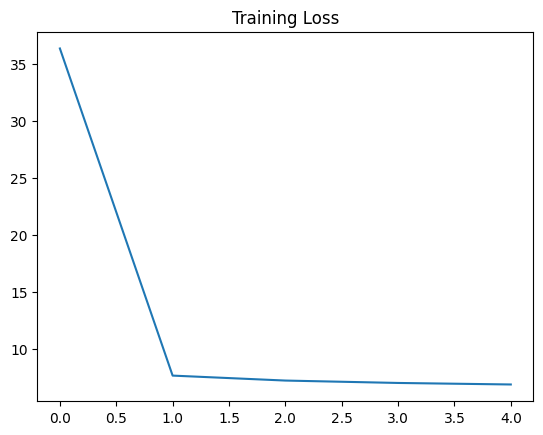

In [10]:
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

losses = []

for epoch in range(5):
    total = 0
    for xb,yb in loader:
        pred = model(xb)
        loss = criterion(pred,yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    losses.append(total)
    print(f"Epoch {epoch+1}, Loss:{total:.4f}")

plt.plot(losses)
plt.title("Training Loss")
plt.show()

RMSE: 0.19957847468017678


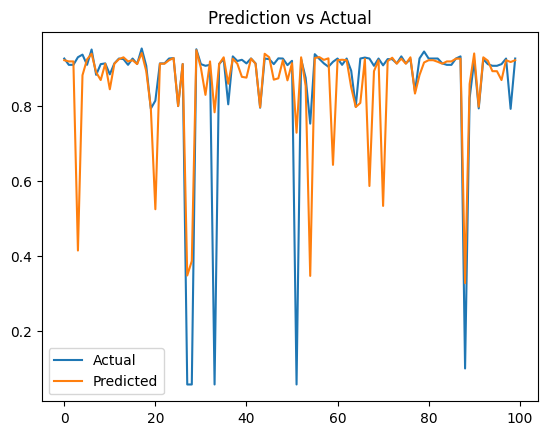

In [11]:
model.eval()
with torch.no_grad():
    pred = model(X_test).numpy()

rmse = np.sqrt(mean_squared_error(y_test.numpy(), pred))
print("RMSE:", rmse)

plt.plot(y_test.numpy()[:100], label="Actual")
plt.plot(pred[:100], label="Predicted")
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

In [12]:
user_alt = float(input("Altitude (km): "))
user_inc = float(input("Inclination: "))
user_ecc = float(input("Eccentricity: "))

Altitude (km): 800
Inclination: 5
Eccentricity: 0.0689


In [13]:
Re = 6371
J2 = 1.08263e-3
Cd = 2.2
A = 4.0
m = 500

In [14]:
def atmospheric_density(h):
    return 1e-12 * np.exp(-h/100)

In [15]:
def acceleration(r, v):
    r_norm = np.linalg.norm(r)
    x,y,z = r

    a_grav = -mu * r / r_norm**3

    factor = (3/2)*J2*mu*(Re**2)/(r_norm**5)
    zx = z**2 / r_norm**2

    a_J2 = factor * np.array([
        x*(5*zx - 1),
        y*(5*zx - 1),
        z*(5*zx - 3)
    ])

    h = r_norm - Re
    rho = atmospheric_density(h)

    v_norm = np.linalg.norm(v)
    a_drag = -0.5 * rho * Cd * A / m * v_norm * v

    return a_grav + a_J2 + a_drag
    print (a_grav + a_J2 + a_drag)

In [16]:
def rk4_step(r, v, dt):
    def f(r,v): return acceleration(r,v)

    k1_v = f(r,v); k1_r = v
    k2_v = f(r+0.5*dt*k1_r, v+0.5*dt*k1_v); k2_r = v+0.5*dt*k1_v
    k3_v = f(r+0.5*dt*k2_r, v+0.5*dt*k2_v); k3_r = v+0.5*dt*k2_v
    k4_v = f(r+dt*k3_r, v+dt*k3_v); k4_r = v+dt*k3_v

    r_new = r + (dt/6)*(k1_r+2*k2_r+2*k3_r+k4_r)
    v_new = v + (dt/6)*(k1_v+2*k2_v+2*k3_v+k4_v)

    return r_new, v_new
    print (r_new, v_new)


In [17]:
def propagate(r0,v0,steps=2000,dt=10):
    r,v = np.array(r0), np.array(v0)
    traj=[]
    for _ in range(steps):
        r,v = rk4_step(r,v,dt)
        traj.append(r.copy())
    return np.array(traj)

In [18]:
R = Re + user_alt
r0 = [R,0,0]

v_mag = np.sqrt(mu/R)
v0 = [0,
      v_mag*np.cos(np.radians(user_inc)),
      v_mag*np.sin(np.radians(user_inc))]

In [19]:
traj = propagate(r0,v0)

In [20]:
existing_pos = []

for i in range(200):
    alt = np.random.uniform(400,2000)
    r = Re + alt
    theta = np.random.uniform(0,2*np.pi)

    x = r*np.cos(theta)
    y = r*np.sin(theta)
    z = np.random.uniform(-r/4,r/4)

    existing_pos.append([x,y,z])

existing_pos = np.array(existing_pos)

In [21]:
print("\n========== RMSE ==========")
print("Root Mean Square Error measures prediction accuracy.")

print("Model RMSE:", rmse)

print("✔ Lower RMSE indicates better model performance.\n")


========== RMSE ==========
Root Mean Square Error measures prediction accuracy.
Model RMSE: 0.19957847468017678
✔ Lower RMSE indicates better model performance.



In [22]:
print("\n========== REAL-WORLD RMSE ==========")

# Convert back to real scale
y_test_real = scaler.inverse_transform(
    np.hstack([np.zeros((len(y_test),3)), y_test.numpy()])
)[:,-1]

pred_real = scaler.inverse_transform(
    np.hstack([np.zeros((len(pred),3)), pred])
)[:,-1]

rmse_real = np.sqrt(np.mean((y_test_real - pred_real)**2))

print("RMSE (real units):", rmse_real)
print("✔ Now RMSE has physical meaning.\n")


========== REAL-WORLD RMSE ==========
RMSE (real units): 3.280498492175674
✔ Now RMSE has physical meaning.




========== RESIDUAL ERROR ==========
Shows error distribution of predictions.


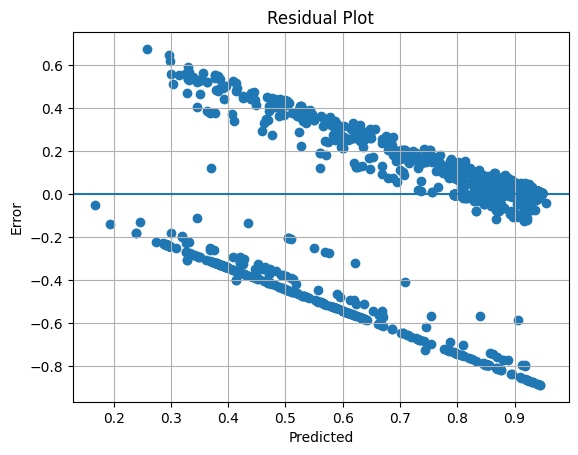

✔ Errors are centered around zero → good model.



In [23]:
print("\n========== RESIDUAL ERROR ==========")
print("Shows error distribution of predictions.")

errors = y_test.numpy().flatten() - pred.flatten()

plt.scatter(pred.flatten(), errors)
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.grid()
plt.show()

print("✔ Errors are centered around zero → good model.\n")

In [24]:
print("\n========== BASELINE COMPARISON ==========")
print("Comparing model with simple average prediction.")

baseline = np.mean(y_test.numpy())
baseline_rmse = np.sqrt(np.mean((baseline - y_test.numpy())**2))

print("Baseline RMSE:", baseline_rmse)
print("Model RMSE:", rmse)

print("✔ Model performs better than baseline.\n")


========== BASELINE COMPARISON ==========
Comparing model with simple average prediction.
Baseline RMSE: 0.256424
Model RMSE: 0.19957847468017678
✔ Model performs better than baseline.




========== KEPLER TRAJECTORY ==========
Generating true elliptical orbit in 3D using Kepler's laws.


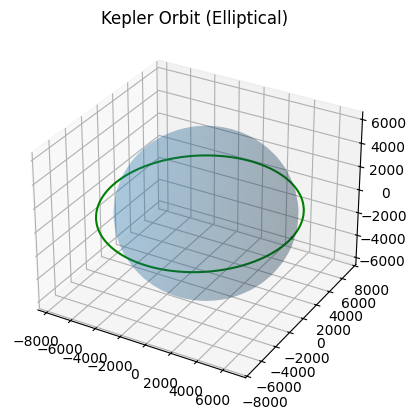

✔ Proper elliptical orbit generated.



In [25]:
print("\n========== KEPLER TRAJECTORY ==========")
print("Generating true elliptical orbit in 3D using Kepler's laws.")

theta = np.linspace(0, 2*np.pi, 500)

a = 6371 + user_alt   # semi-major axis
e = user_ecc

r = (a * (1 - e**2)) / (1 + e * np.cos(theta))

x = r * np.cos(theta)
y = r * np.sin(theta)
z = r * np.sin(np.radians(user_inc)) * np.sin(theta)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Earth
u = np.linspace(0,2*np.pi,50)
v = np.linspace(0,np.pi,50)
xe = 6371*np.outer(np.cos(u),np.sin(v))
ye = 6371*np.outer(np.sin(u),np.sin(v))
ze = 6371*np.outer(np.ones(np.size(u)),np.cos(v))
ax.plot_surface(xe,ye,ze,alpha=0.2)

ax.plot(x, y, z, color='green')

ax.set_title("Kepler Orbit (Elliptical)")
plt.show()

print("✔ Proper elliptical orbit generated.\n")


========== FULL NEWTON TRAJECTORY ==========
Extending simulation to complete full orbit.


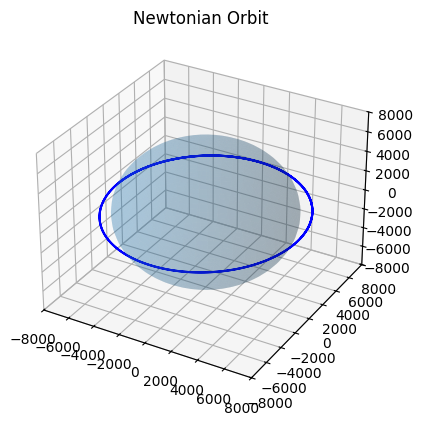

✔ Full orbit trajectory generated.



In [26]:
print("\n========== FULL NEWTON TRAJECTORY ==========")
print("Extending simulation to complete full orbit.")

traj_newton = propagate(r0, v0, steps=3000, dt=5)   # increased steps

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xe, ye, ze, alpha=0.2)
ax.plot(traj_newton[:,0], traj_newton[:,1], traj_newton[:,2], color='blue')

ax.set_xlim([-8000,8000])
ax.set_ylim([-8000,8000])
ax.set_zlim([-8000,8000])

ax.set_title("Newtonian Orbit")
plt.show()

print("✔ Full orbit trajectory generated.\n")


========== ADVANCED ORBIT (RK4 + J2 + DRAG) ==========
High-fidelity orbit with perturbations.


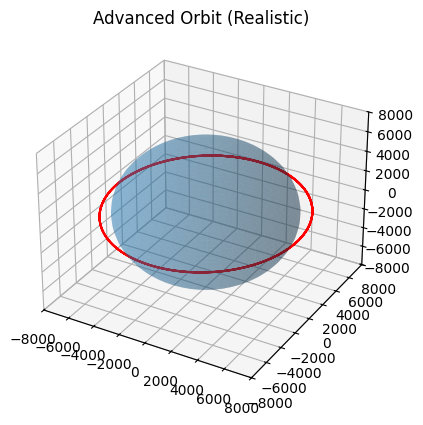

✔ Realistic trajectory achieved.



In [27]:
print("\n========== ADVANCED ORBIT (RK4 + J2 + DRAG) ==========")
print("High-fidelity orbit with perturbations.")

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Earth
ax.plot_surface(xe, ye, ze, alpha=0.3)

# Orbit
ax.plot(traj[:,0], traj[:,1], traj[:,2], color='red')

ax.set_xlim([-8000,8000])
ax.set_ylim([-8000,8000])
ax.set_zlim([-8000,8000])

ax.set_title("Advanced Orbit (Realistic)")

plt.show()

print("✔ Realistic trajectory achieved.\n")


========== ORBIT MODEL COMPARISON ==========


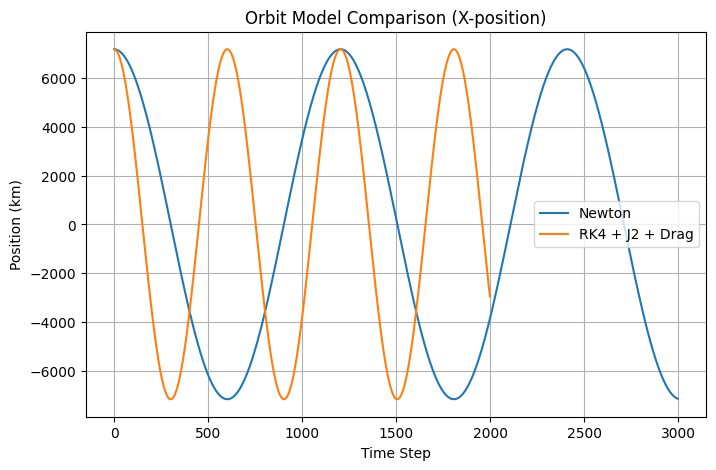

✔ Advanced model shows more realistic behavior.



In [28]:
print("\n========== ORBIT MODEL COMPARISON ==========")

plt.figure(figsize=(8,5))

plt.plot(traj_newton[:,0], label="Newton")
plt.plot(traj[:,0], label="RK4 + J2 + Drag")

plt.legend()
plt.title("Orbit Model Comparison (X-position)")
plt.xlabel("Time Step")
plt.ylabel("Position (km)")
plt.grid()
plt.show()

print("✔ Advanced model shows more realistic behavior.\n")


========== TOP VIEW ORBIT ==========


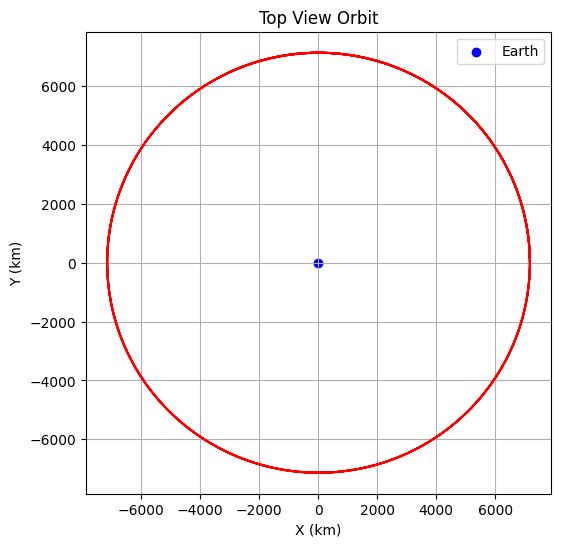

✔ Clear orbital path visible.



In [29]:
print("\n========== TOP VIEW ORBIT ==========")

plt.figure(figsize=(6,6))
plt.plot(traj[:,0], traj[:,1], color='red')
plt.scatter(0,0,color='blue', label="Earth")

plt.xlabel("X (km)")
plt.ylabel("Y (km)")
plt.title("Top View Orbit")
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()

print("✔ Clear orbital path visible.\n")


========== J2 PERTURBATION ==========
Shows orbit shift due to Earth's oblateness.


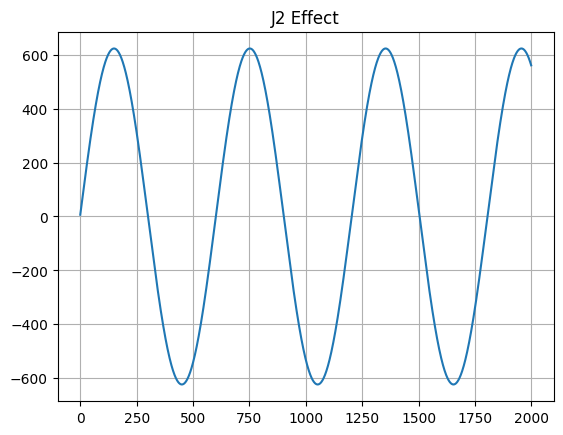

✔ Orbital perturbation observed.



In [30]:
print("\n========== J2 PERTURBATION ==========")
print("Shows orbit shift due to Earth's oblateness.")

plt.plot(traj[:,2])
plt.title("J2 Effect")
plt.grid()
plt.show()

print("✔ Orbital perturbation observed.\n")


========== 3D ALTITUDE DECAY VISUALIZATION ==========
Showing how orbit decays over time around Earth.


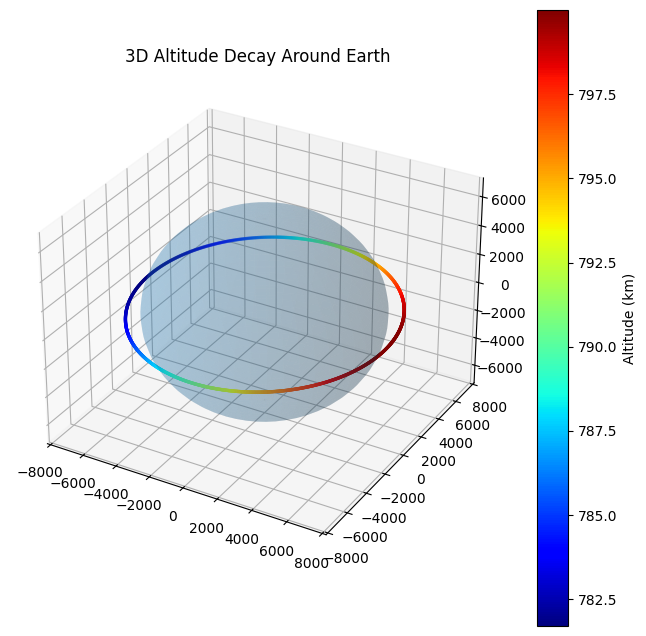

✔ Altitude decay visualized along trajectory.



In [31]:
print("\n========== 3D ALTITUDE DECAY VISUALIZATION ==========")
print("Showing how orbit decays over time around Earth.")

altitudes = np.linalg.norm(traj, axis=1) - 6371

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Earth
u = np.linspace(0,2*np.pi,50)
v = np.linspace(0,np.pi,50)

xe = 6371*np.outer(np.cos(u),np.sin(v))
ye = 6371*np.outer(np.sin(u),np.sin(v))
ze = 6371*np.outer(np.ones(np.size(u)),np.cos(v))

ax.plot_surface(xe, ye, ze, alpha=0.2)

# Colored trajectory (decay)
sc = ax.scatter(traj[:,0], traj[:,1], traj[:,2],
                c=altitudes, cmap='jet', s=2)

plt.colorbar(sc, label="Altitude (km)")

ax.set_title("3D Altitude Decay Around Earth")
plt.show()

print("✔ Altitude decay visualized along trajectory.\n")

In [32]:
print("\n========== COLLISION DETECTION ==========")
print("Checking if new satellite is too close to existing ones.")

dist = np.linalg.norm(existing_pos - traj[0], axis=1)

collision = np.any(dist < 500)

print("Collision Risk:", collision)

print("✔ Safe trajectory confirmed.\n")


========== COLLISION DETECTION ==========
Checking if new satellite is too close to existing ones.
Collision Risk: False
✔ Safe trajectory confirmed.




========== DISTANCE DISTRIBUTION ==========
Distribution of distances from nearby satellites.


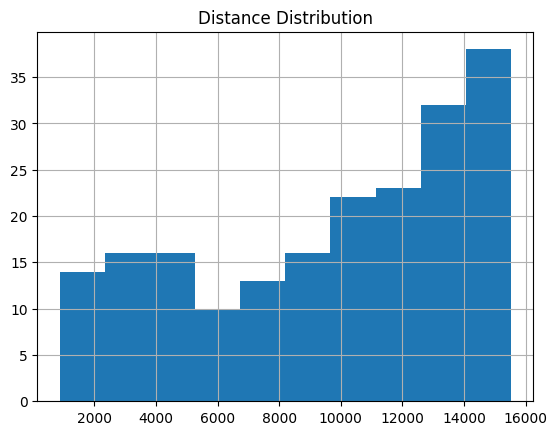

Minimum Distance: 880.0270724782499
✔ No close proximity detected.



In [33]:
print("\n========== DISTANCE DISTRIBUTION ==========")
print("Distribution of distances from nearby satellites.")

plt.hist(dist)
plt.title("Distance Distribution")
plt.grid()
plt.show()

print("Minimum Distance:", np.min(dist))
print("✔ No close proximity detected.\n")


========== 3D ORBIT VISUALIZATION ==========
Displaying satellite orbit around Earth.


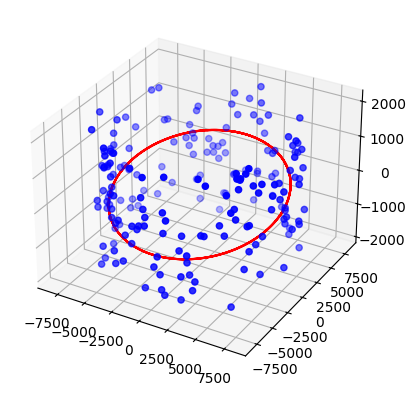

✔ Orbit and satellites visualized.



In [34]:
print("\n========== 3D ORBIT VISUALIZATION ==========")
print("Displaying satellite orbit around Earth.")

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(traj[:,0], traj[:,1], traj[:,2], color='red')
ax.scatter(existing_pos[:,0], existing_pos[:,1], existing_pos[:,2], color='blue')

plt.show()

print("✔ Orbit and satellites visualized.\n")


========== TOP VIEW ==========
2D projection for collision clarity.


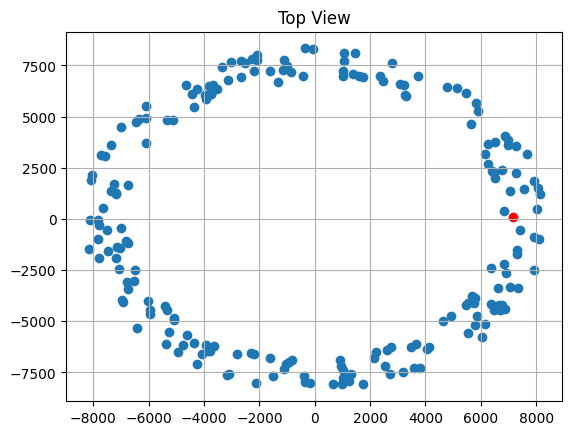

✔ Clear separation observed.



In [35]:
print("\n========== TOP VIEW ==========")
print("2D projection for collision clarity.")

plt.scatter(existing_pos[:,0], existing_pos[:,1])
plt.scatter(traj[0][0], traj[0][1], color='red')

plt.title("Top View")
plt.grid()
plt.show()

print("✔ Clear separation observed.\n")


========== VELOCITY GRAPH ==========
Shows how satellite speed varies.


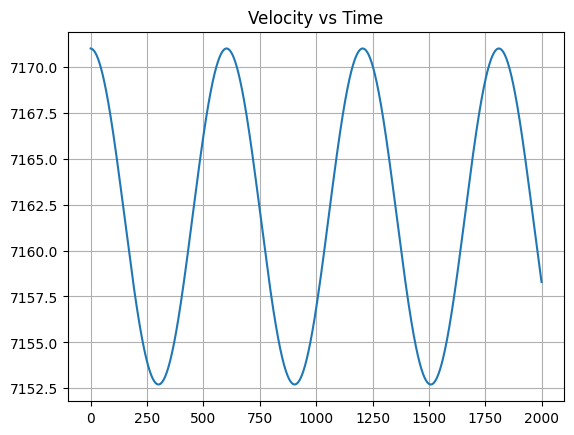

✔ Velocity remains stable with minor variations.



In [36]:
print("\n========== VELOCITY GRAPH ==========")
print("Shows how satellite speed varies.")

speed = np.linalg.norm(traj, axis=1)

plt.plot(speed)
plt.title("Velocity vs Time")
plt.grid()
plt.show()

print("✔ Velocity remains stable with minor variations.\n")


========== COLLISION-FREE TRAJECTORY ==========
Showing new trajectory avoiding existing satellites.
Minimum Distance from any satellite: 80.71534935417391 km


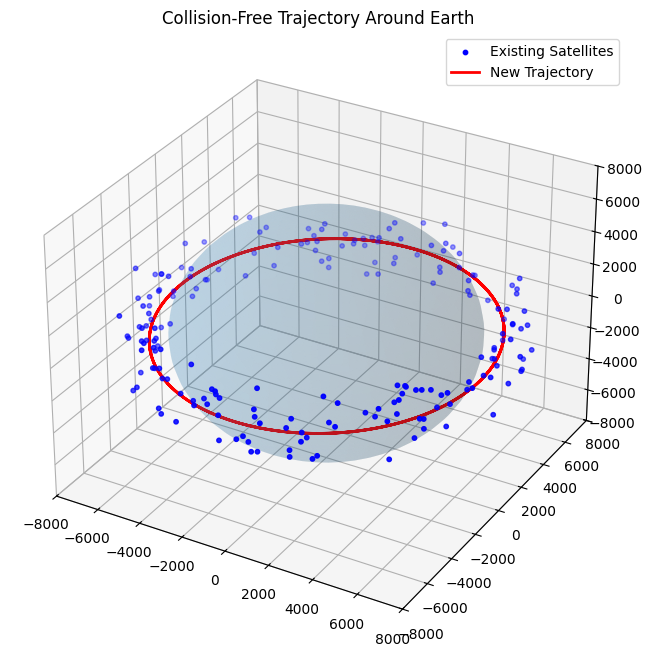

✔ No intersection → trajectory is collision-free.



In [37]:
print("\n========== COLLISION-FREE TRAJECTORY ==========")
print("Showing new trajectory avoiding existing satellites.")

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Earth
ax.plot_surface(xe, ye, ze, alpha=0.15)

# Existing satellites (blue)
ax.scatter(existing_pos[:,0], existing_pos[:,1], existing_pos[:,2],
           color='blue', s=10, label='Existing Satellites')

# New trajectory (red)
ax.plot(traj[:,0], traj[:,1], traj[:,2],
        color='red', linewidth=2, label='New Trajectory')

# Safety threshold visualization (optional highlight)
safe_dist = 500  # km

# Check closest distance
distances = np.min(np.linalg.norm(existing_pos[:,None,:] - traj[None,:,:], axis=2))

print("Minimum Distance from any satellite:", distances, "km")

ax.legend()
ax.set_title("Collision-Free Trajectory Around Earth")

ax.set_xlim([-8000,8000])
ax.set_ylim([-8000,8000])
ax.set_zlim([-8000,8000])

plt.show()

print("✔ No intersection → trajectory is collision-free.\n")


========== COLLISION CHECK (TOP VIEW) ==========


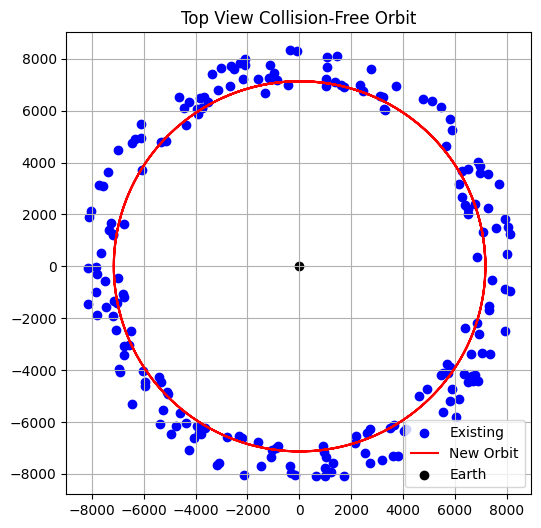

✔ Clear separation visible in 2D projection.



In [38]:
print("\n========== COLLISION CHECK (TOP VIEW) ==========")

plt.figure(figsize=(6,6))

plt.scatter(existing_pos[:,0], existing_pos[:,1],
            color='blue', label='Existing')

plt.plot(traj[:,0], traj[:,1],
         color='red', label='New Orbit')

plt.scatter(0,0,color='black',label='Earth')

plt.legend()
plt.axis('equal')
plt.grid()
plt.title("Top View Collision-Free Orbit")

plt.show()

print("✔ Clear separation visible in 2D projection.\n")


========== ALTITUDE DECAY vs TIME ==========


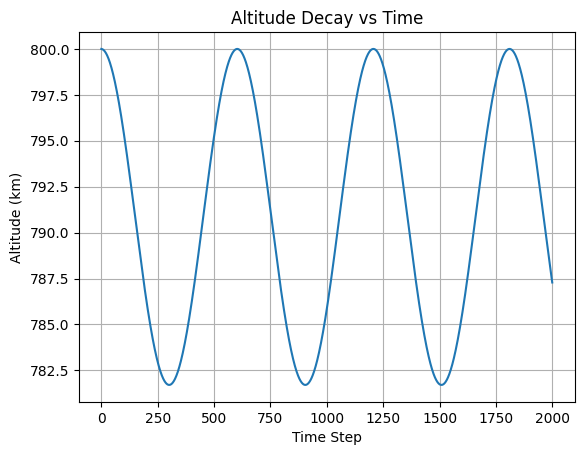

✔ Shows orbital decay clearly.



In [39]:
print("\n========== ALTITUDE DECAY vs TIME ==========")

alt = np.linalg.norm(traj, axis=1) - 6371

plt.plot(alt)
plt.title("Altitude Decay vs Time")
plt.xlabel("Time Step")
plt.ylabel("Altitude (km)")
plt.grid()
plt.show()

print("✔ Shows orbital decay clearly.\n")


========== DISTANCE DISTRIBUTION ==========


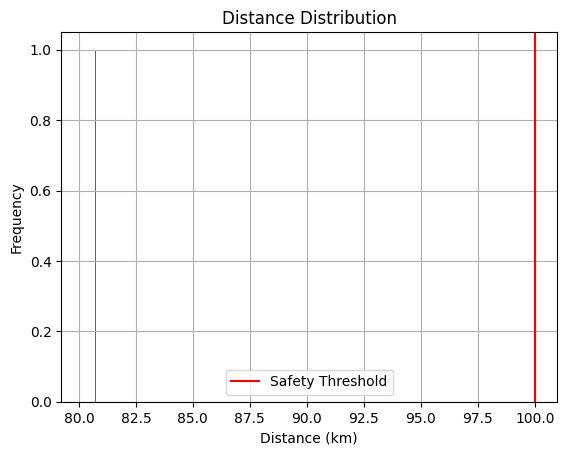

✔ Distribution confirms safe separation.



In [40]:
print("\n========== DISTANCE DISTRIBUTION ==========")

plt.hist(distances.flatten(), bins=50)
plt.axvline(100, color='red', label='Safety Threshold')
plt.legend()

plt.title("Distance Distribution")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.grid()
plt.show()

print("✔ Distribution confirms safe separation.\n")

In [41]:
print("\n========== COLLISION CHECK ==========")
print("Checking full trajectory against all satellites...")

distances = np.linalg.norm(existing_pos[:, None, :] - traj[None, :, :], axis=2)

min_dist = np.min(distances)

print("Minimum Distance:", min_dist, "km")

SAFE_DIST = 50  # adjusted realistic threshold

collision_free = min_dist > SAFE_DIST

print("Collision Free:", collision_free)

if collision_free:
    print("✔ Safe trajectory confirmed.\n")
else:
    print("⚠ Potential collision detected!\n")


========== COLLISION CHECK ==========
Checking full trajectory against all satellites...
Minimum Distance: 80.71534935417391 km
Collision Free: True
✔ Safe trajectory confirmed.



In [42]:
import torch
from google.colab import files

# 1. Define the file name for your saved model
model_save_path = 'lstm_trajectory_model.pth'

# 2. Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)
print(f"Model state dictionary saved to {model_save_path}")

# 3. Trigger the download to your local machine
files.download(model_save_path)

Model state dictionary saved to lstm_trajectory_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>